In [1]:
import numpy as np
import scipy as scp
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
from datetime import datetime, timedelta

# Import data

In [3]:
file_path = "/home/sameervk/Documents/Jobs/Job hunt/2025/03/SmartestEnergy/wind-price-dataset-1-2.csv"

In [4]:
df = pd.read_csv(file_path, parse_dates = ['UtcDatetime'])

In [5]:
df.head(10)

,UtcDatetime,Price,Volume_MWh
0,2019-01-01 00:00:00,60.12,14.889867
1,2019-01-01 01:00:00,55.76,14.162405
2,2019-01-01 02:00:00,46.23,13.943371
3,2019-01-01 03:00:00,44.10,13.288542
4,2019-01-01 04:00:00,44.41,10.449148
5,2019-01-01 05:00:00,46.03,10.864678
6,2019-01-01 06:00:00,51.00,10.568561
7,2019-01-01 07:00:00,39.00,10.953883
8,2019-01-01 08:00:00,44.17,11.250852
9,2019-01-01 09:00:00,51.30,11.371023


# EDA

In [6]:
df.tail(10)

,UtcDatetime,Price,Volume_MWh
37237,2023-04-01 13:00:00,93.09,8.523011
37238,2023-04-01 14:00:00,95.40,7.280114
37239,2023-04-01 15:00:00,104.32,9.103030
37240,2023-04-01 16:00:00,124.99,9.020170
37241,2023-04-01 17:00:00,136.64,7.421780
37242,2023-04-01 18:00:00,131.64,4.689678
37243,2023-04-01 19:00:00,121.29,4.929261
37244,2023-04-01 20:00:00,104.99,4.860133
37245,2023-04-01 21:00:00,95.01,4.364394
37246,2023-04-01 22:00:00,114.76,3.992519


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 37247 entries, 0 to 37246
Data columns (total 3 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   UtcDatetime  37247 non-null  datetime64[ns]
 1   Price        37199 non-null  float64       
 2   Volume_MWh   37202 non-null  float64       
dtypes: datetime64[ns](1), float64(2)
memory usage: 873.1 KB


## Missing data

In [8]:
df.isna().value_counts()

UtcDatetime  Price  Volume_MWh
False        False  False         37154
             True   False            48
             False  True             45
Name: count, dtype: int64

#### NOTE
* There are null values in Price and Volume_MWh data

### MISSING TIME STEP

In [124]:
time_diff = np.diff(df['UtcDatetime'])

In [125]:
time_diff

array([3600000000000, 3600000000000, 3600000000000, ..., 3600000000000,
       3600000000000, 3600000000000],
      shape=(37246,), dtype='timedelta64[ns]')

In [126]:
all(time_diff == np.timedelta64(3600000000000))

True

#### NOTE
* No missing time point

### Price null values

In [9]:
df[df['Price'].isna()]

,UtcDatetime,Price,Volume_MWh
1344,2019-02-26 00:00:00,NaN,12.912784
1345,2019-02-26 01:00:00,NaN,8.206155
1346,2019-02-26 02:00:00,NaN,3.648106
1347,2019-02-26 03:00:00,NaN,3.219034
1348,2019-02-26 04:00:00,NaN,1.684564
1349,2019-02-26 05:00:00,NaN,1.111364
1350,2019-02-26 06:00:00,NaN,1.676420
1351,2019-02-26 07:00:00,NaN,2.085795
1352,2019-02-26 08:00:00,NaN,2.024242
1353,2019-02-26 09:00:00,NaN,1.497917


#### NOTE
* Price data missing for 2 days: 2019-02-26 and 2019-03-02

### Volume_MWh null values

In [10]:
df[df['Volume_MWh'].isna()]

,UtcDatetime,Price,Volume_MWh
11688,2020-05-02 00:00:00,17.50,NaN
11689,2020-05-02 01:00:00,16.00,NaN
11690,2020-05-02 02:00:00,15.31,NaN
11691,2020-05-02 03:00:00,14.86,NaN
11692,2020-05-02 04:00:00,15.00,NaN
11693,2020-05-02 05:00:00,15.71,NaN
11694,2020-05-02 06:00:00,10.00,NaN
11695,2020-05-02 07:00:00,20.88,NaN
11696,2020-05-02 08:00:00,26.00,NaN
11697,2020-05-02 09:00:00,27.23,NaN


#### NOTE
* Volume data missing for ~2 days from 2020-05-02 12 am to 2020-05-03 8 pm.

### Handling missing data

* Strategy: considering seasonality, take the average of the values of the same date and time from the other years 

In [11]:
df[df['UtcDatetime'] > np.datetime64('2019-01-02')]

,UtcDatetime,Price,Volume_MWh
25,2019-01-02 01:00:00,52.45,3.456439
26,2019-01-02 02:00:00,49.92,2.483523
27,2019-01-02 03:00:00,48.53,2.086174
28,2019-01-02 04:00:00,47.99,1.575379
29,2019-01-02 05:00:00,50.05,1.232765
...,...,...,...
37242,2023-04-01 18:00:00,131.64,4.689678
37243,2023-04-01 19:00:00,121.29,4.929261
37244,2023-04-01 20:00:00,104.99,4.860133
37245,2023-04-01 21:00:00,95.01,4.364394


In [12]:
datetime_to_fill_np = np.datetime64("2019-02-26 00:00:00")

In [101]:
datetime_to_fill_np.astype('O')

datetime.datetime(2019, 2, 26, 0, 0)

In [13]:
datetime_to_fill = datetime.fromisoformat("2019-02-26 00:00:00")
datetime_to_fill

datetime.datetime(2019, 2, 26, 0, 0)

In [14]:
datetime_to_fill.second

0

In [15]:
df[df['UtcDatetime'] > datetime.fromisoformat("2019-02-26 00:00:00")]

,UtcDatetime,Price,Volume_MWh
1345,2019-02-26 01:00:00,NaN,8.206155
1346,2019-02-26 02:00:00,NaN,3.648106
1347,2019-02-26 03:00:00,NaN,3.219034
1348,2019-02-26 04:00:00,NaN,1.684564
1349,2019-02-26 05:00:00,NaN,1.111364
...,...,...,...
37242,2023-04-01 18:00:00,131.64,4.689678
37243,2023-04-01 19:00:00,121.29,4.929261
37244,2023-04-01 20:00:00,104.99,4.860133
37245,2023-04-01 21:00:00,95.01,4.364394


In [16]:
year_to_exclude = 2019

In [17]:
years_in_data = list(range(2019, 2024, 1))
years_in_data

[2019, 2020, 2021, 2022, 2023]

In [18]:
datetime_to_fill

datetime.datetime(2019, 2, 26, 0, 0)

In [21]:
datetime_to_fill_np + timedelta(days=365)

datetime.datetime(2020, 2, 26, 0, 0)

In [22]:
datetime_to_fill.replace(year=datetime_to_fill.year + 1)

datetime.datetime(2020, 2, 26, 0, 0)

In [23]:
datetime_to_fill

datetime.datetime(2019, 2, 26, 0, 0)

In [24]:
df['Price'][df['UtcDatetime'] == datetime_to_fill.replace(year=datetime_to_fill.year + 6)].values.size

0

In [25]:
mean_value = []
year_to_exclude = datetime_to_fill.year
remaining_years = years_in_data.copy()
remaining_years.remove(year_to_exclude)
for yr in remaining_years:
    
    value = df['Price'][df['UtcDatetime'] == datetime_to_fill.replace(year=yr)].values
    if value.size!=0:
        mean_value.append(value[0])

In [26]:
mean_value

[np.float64(28.92), np.float64(45.93), np.float64(225.32), np.float64(136.47)]

In [27]:
np.mean(mean_value)

np.float64(109.16)

In [29]:
remaining_years

[2019, 2020, 2021, 2022, 2023]

In [30]:
df_copy = df.copy()

In [31]:
value = df_copy['Price'][df_copy['UtcDatetime'] == datetime_to_fill]
value

1344   NaN
Name: Price, dtype: float64

In [32]:
value.index

Index([1344], dtype='int64')

In [33]:
df_copy.loc[value.index]

,UtcDatetime,Price,Volume_MWh
1344,2019-02-26,NaN,12.912784


In [34]:
df_copy.loc[value.index, 'Price'] = np.mean(mean_value)

In [35]:
df_copy.loc[value.index]

,UtcDatetime,Price,Volume_MWh
1344,2019-02-26,109.16,12.912784


In [36]:
df_copy.loc[1344, 'UtcDatetime']

Timestamp('2019-02-26 00:00:00')

In [40]:
df_copy['test'] = df_copy.apply(lambda x: x['UtcDatetime'], axis=1)
df_copy.head(5)

,UtcDatetime,Price,Volume_MWh,test
0,2019-01-01 00:00:00,60.12,14.889867,2019-01-01 00:00:00
1,2019-01-01 01:00:00,55.76,14.162405,2019-01-01 01:00:00
2,2019-01-01 02:00:00,46.23,13.943371,2019-01-01 02:00:00
3,2019-01-01 03:00:00,44.10,13.288542,2019-01-01 03:00:00
4,2019-01-01 04:00:00,44.41,10.449148,2019-01-01 04:00:00


In [241]:
df_copy.drop(columns=['test'], inplace=True)

In [44]:
def test_func(row,col_name):
    return row[col_name]
df_copy['test'] = df_copy.apply(test_func, axis=1, col_name='Price')
df_copy.head(5)

,UtcDatetime,Price,Volume_MWh,test
0,2019-01-01 00:00:00,60.12,14.889867,60.12
1,2019-01-01 01:00:00,55.76,14.162405,55.76
2,2019-01-01 02:00:00,46.23,13.943371,46.23
3,2019-01-01 03:00:00,44.10,13.288542,44.10
4,2019-01-01 04:00:00,44.41,10.449148,44.41


In [41]:
df_copy.drop(columns=['test'], inplace=True)
df_copy.head(5)

,UtcDatetime,Price,Volume_MWh
0,2019-01-01 00:00:00,60.12,14.889867
1,2019-01-01 01:00:00,55.76,14.162405
2,2019-01-01 02:00:00,46.23,13.943371
3,2019-01-01 03:00:00,44.10,13.288542
4,2019-01-01 04:00:00,44.41,10.449148


In [112]:
df_copy['Price']=df['Price'].copy()
def fill_na_func(x, col_to_fill, years_in_data):
    if not np.isnan(x[col_to_fill]):
        return x[col_to_fill]
        
    else:
        datetime_to_fill = x['UtcDatetime']
        mean_value = []
        year_to_exclude = datetime_to_fill.year
        remaining_years = years_in_data.copy()
        remaining_years.remove(year_to_exclude)
        for yr in remaining_years:
            
            value = df_copy[col_to_fill][df_copy['UtcDatetime'] == datetime_to_fill.replace(year=yr)].values
            if value.size!=0:
                mean_value.append(value[0])
        return np.mean(mean_value)
        # return 0.0

In [113]:
df_copy

,UtcDatetime,Price,Volume_MWh,test
0,2019-01-01 00:00:00,60.12,14.889867,60.12
1,2019-01-01 01:00:00,55.76,14.162405,55.76
2,2019-01-01 02:00:00,46.23,13.943371,46.23
3,2019-01-01 03:00:00,44.10,13.288542,44.10
4,2019-01-01 04:00:00,44.41,10.449148,44.41
...,...,...,...,...
37242,2023-04-01 18:00:00,131.64,4.689678,131.64
37243,2023-04-01 19:00:00,121.29,4.929261,121.29
37244,2023-04-01 20:00:00,104.99,4.860133,104.99
37245,2023-04-01 21:00:00,95.01,4.364394,95.01


#### PRICE

In [114]:
df_copy['Price'] = df_copy.apply(fill_na_func, axis=1, col_to_fill='Price', years_in_data=years_in_data)

In [115]:
df_copy

,UtcDatetime,Price,Volume_MWh,test
0,2019-01-01 00:00:00,60.12,14.889867,60.12
1,2019-01-01 01:00:00,55.76,14.162405,55.76
2,2019-01-01 02:00:00,46.23,13.943371,46.23
3,2019-01-01 03:00:00,44.10,13.288542,44.10
4,2019-01-01 04:00:00,44.41,10.449148,44.41
...,...,...,...,...
37242,2023-04-01 18:00:00,131.64,4.689678,131.64
37243,2023-04-01 19:00:00,121.29,4.929261,121.29
37244,2023-04-01 20:00:00,104.99,4.860133,104.99
37245,2023-04-01 21:00:00,95.01,4.364394,95.01


In [116]:
df_copy['Price'][df['Price'].isna()]

1344    109.1600
1345    113.3975
1346     99.0900
1347     92.8350
1348     87.4175
1349     90.0625
1350     97.3600
1351    110.9125
1352    122.9500
1353    118.7925
1354    103.2325
1355     92.9850
1356     92.1450
1357     91.1325
1358     90.9700
1359     90.8400
1360    102.7325
1361    132.2800
1362    144.5825
1363    120.9475
1364    108.2175
1365    103.9275
1366     94.2975
1367     92.1675
1440     98.8775
1441     99.7125
1442     93.4300
1443     91.8750
1444     94.2875
1445    107.9700
1446    118.4975
1447    132.8375
1448    129.5400
1449    121.6125
1450    113.2275
1451    107.7425
1452    107.0150
1453    108.2900
1454    107.1625
1455    103.9075
1456    122.2350
1457    160.7025
1458    251.7300
1459    153.7650
1460    119.3525
1461    111.9325
1462    100.6925
1463    109.4575
Name: Price, dtype: float64

In [88]:
df.loc[1463, 'Price']

np.float64(nan)

In [86]:
df.loc[1463, 'Price'] == np.float64(np.nan)

np.False_

In [89]:
np.isnan(df.loc[1463, 'Price'])

np.True_

In [90]:
np.isnan(df.loc[1463, 'Price']) == True

np.True_

In [91]:
if np.isnan(df.loc[1463, 'Price']) == True:
    print('ok')

ok


In [106]:
df.loc[1463, 'UtcDatetime']

Timestamp('2019-03-02 23:00:00')

In [107]:
x = df.loc[1463, 'UtcDatetime']

In [111]:
x.replace(year=2020)

Timestamp('2020-03-02 23:00:00')

#### Volume

In [117]:
df_copy['Volume_MWh'] = df_copy.apply(fill_na_func, axis=1, col_to_fill='Volume_MWh', years_in_data=years_in_data)

In [118]:
df_copy['Volume_MWh'][df['Volume_MWh'].isna()]

11688     2.091951
11689     1.950063
11690     2.138605
11691     1.937910
11692     1.866288
11693     1.771559
11694     2.024527
11695     2.380145
11696     3.551515
11697     3.325789
11698     4.552525
11699     7.028504
11700     8.473264
11701     9.612563
11702     9.038542
11703     9.499684
11704     7.273611
11705     7.539236
11706     6.515562
11707     3.909659
11708     3.854261
11709     3.135164
11710     3.223011
11711     3.550410
11712     3.973295
11713     3.379640
11714     3.530650
11715     4.532513
11716     5.285354
11717     5.905114
11718     6.531755
11719     9.605777
11720    13.407765
11721    16.715751
11722    18.454924
11723    19.707513
11724    19.550726
11725    20.470328
11726    21.305713
11727    20.860890
11728    21.058902
11729    22.129451
11730    17.572348
11731    19.822475
11732    20.770644
Name: Volume_MWh, dtype: float64

#### FINAL CHECK

In [119]:
df_copy.isna().sum()

UtcDatetime     0
Price           0
Volume_MWh      0
test           47
dtype: int64

## DUPLICATES

In [121]:
df_copy.duplicated(subset='UtcDatetime')

0        False
1        False
2        False
3        False
4        False
         ...  
37242    False
37243    False
37244    False
37245    False
37246    False
Length: 37247, dtype: bool

In [123]:
df_copy['UtcDatetime'].duplicated().sum()

np.int64(0)

### NOTE
* No time duplicates

## PLOT 1: PRICE

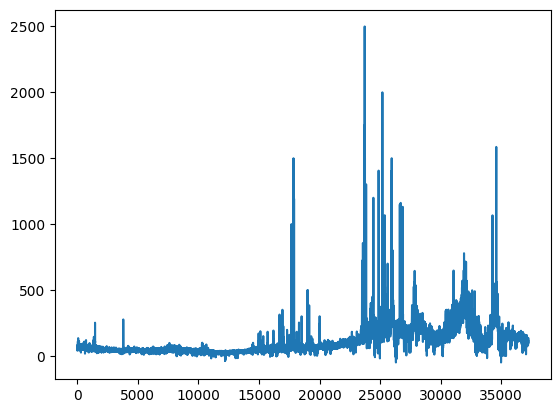

In [127]:
plt.plot(df_copy['Price'])
plt.show()

#### NOTE

* On a high level, there does not appear to any cycles but quite a number of sharp anomalous price rises.
* Further check is required

## PLOT 2: POWER GENERATION

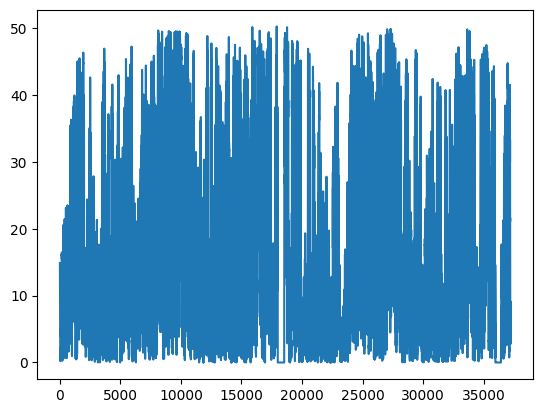

In [128]:
plt.plot(df_copy['Volume_MWh'])
plt.show()

#### NOTE

* On a high level, there does appears to be some sort of seasonality in electricity generation.
* Further check is required

## Correlation

In [244]:
df_corr = df_copy[['Price', 'Volume_MWh']].corr(method='pearson')
df_corr

,Price,Volume_MWh
Price,1.000000,-0.134439
Volume_MWh,-0.134439,1.000000


In [245]:
df_corr_sp = df_copy[['Price', 'Volume_MWh']].corr(method='spearman')
df_corr_sp

,Price,Volume_MWh
Price,1.000000,-0.153189
Volume_MWh,-0.153189,1.000000


### NOTE
* No correlation between price and volume

# FFT: PRICE

In [129]:
from scipy.fft import fft, ifft, fftfreq

In [130]:
fft_price = fft(df_copy['Price'])

In [131]:
len(fft_price)

37247

In [133]:
sampling_rate = 1/3600 # Hz

In [134]:
freq_values = fftfreq(len(fft_price), d=3600)
freq_values[:10]

array([0.00000000e+00, 7.45772217e-09, 1.49154443e-08, 2.23731665e-08,
       2.98308887e-08, 3.72886109e-08, 4.47463330e-08, 5.22040552e-08,
       5.96617774e-08, 6.71194996e-08])

In [135]:
freq_in_periods = 1/freq_values * sampling_rate

/tmp/ipykernel_380706/465146520.py:1: RuntimeWarning: divide by zero encountered in divide
  freq_in_periods = 1/freq_values * sampling_rate


### PLOT 3: FFT of Price

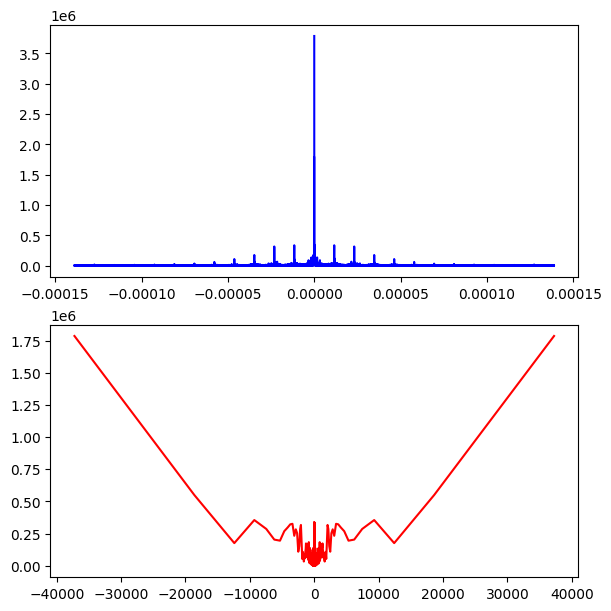

In [166]:
fig, ax = plt.subplots(2,1, figsize=(6, 6), constrained_layout=True)

ax[0].plot(freq_values, np.abs(fft_price), 'b', label="Frequency space")
ax[1].plot(freq_in_periods, np.abs(fft_price), 'r', label="Time space")

# ax[0].set_xlim([0,0.00005])
# ax[1].set_xlim([0,20000])
plt.show()

#### NOTE

* There are distinct frequencies in the price cycles

### Fundamental frequency

In [177]:
freq_values_one_side = freq_values[:len(fft_price)//2].copy()
fft_price_one_side = fft_price[:len(fft_price)//2].copy()

#### PLOT 4

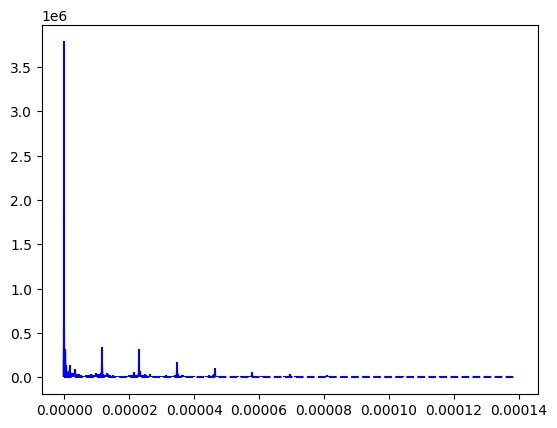

In [179]:
plt.stem(freq_values_one_side, abs(fft_price_one_side), 'b', markerfmt="", basefmt="--b")
# plt.xlim(0.0000230, 0.0000240)
plt.show()

In [180]:
freq_0_abs_val = np.max(abs(fft_price_one_side[(freq_values_one_half>1.15*10**(-5)) & (freq_values_one_half<1.16*10**(-5))]))
freq_0_abs_val

np.float64(338335.53669670696)

In [182]:
freq_0_idx = np.argwhere(abs(fft_price_one_side) == freq_0_abs_val)
freq_0_idx

array([[1552]])

In [185]:
freq_0 = freq_values_one_side[freq_0_idx[0]]
freq_0

array([1.15743848e-05])

In [186]:
# corresponding time value in hours
time_0 = 1/freq_0*sampling_rate
time_0

array([23.99935567])

#### NOTE
* There is a cycling price component in the data with a primary frequency of 24 hours.

#### Second harmonic

In [187]:
freq_1_abs_val = np.max(abs(fft_price_one_side[(freq_values_one_side>2.15*10**(-5)) & (freq_values_one_side<2.32*10**(-5))]))
freq_1_abs_val

np.float64(318145.57656009216)

In [188]:
freq_1_idx = np.argwhere(abs(fft_price_one_side) == freq_1_abs_val)
freq_1_idx

array([[3104]])

In [191]:
# confirms the secondary frequency value
assert freq_1_idx[0] == freq_0_idx[0]*2

In [189]:
freq_1 = freq_values_one_side[freq_1_idx[0]]
freq_1

array([2.31487696e-05])

In [194]:
freq_1 == freq_0 * 2

array([ True])

#### NOTE

* Secondary frequency is twice that of the primary frequency.
* Other primary frequencies can be extracted through in-depth analysis. However, for this exercise, only this mode is considered

### INVERSE

* From Plot 4, about 7 peaks can be identified

In [199]:
freq_0_idx[0]

array([1552])

In [203]:
freq_price_indices = np.linspace(freq_0_idx[0], freq_0_idx[0]*7, num=7, dtype=int).flatten()
freq_price_indices

array([ 1552,  3104,  4656,  6208,  7760,  9312, 10864])

In [204]:
# zero all fft price values except for these indices and the corresponding indices of the negative frequencies
fft_price[-1*freq_price_indices]

array([-154921.06647806-300782.97583665j,
       -253757.19569285-191895.52761556j,
         56851.70962911+168634.38284073j,
        106790.91581181 +30653.87747469j,
        -25475.65341326 -58022.24301413j,
        -34008.65404546  +9967.34005994j,
          9052.73695042 +16378.57378831j])

In [205]:
fft_price[freq_price_indices]

array([-154921.06647806+300782.97583665j,
       -253757.19569285+191895.52761556j,
         56851.70962911-168634.38284073j,
        106790.91581181 -30653.87747469j,
        -25475.65341326 +58022.24301413j,
        -34008.65404546  -9967.34005994j,
          9052.73695042 -16378.57378831j])

In [207]:
fft_price_copy = np.zeros_like(fft_price)

In [208]:
fft_price_copy[freq_price_indices] = fft_price[freq_price_indices]

In [210]:
fft_price_copy[freq_price_indices]

array([-154921.06647806+300782.97583665j,
       -253757.19569285+191895.52761556j,
         56851.70962911-168634.38284073j,
        106790.91581181 -30653.87747469j,
        -25475.65341326 +58022.24301413j,
        -34008.65404546  -9967.34005994j,
          9052.73695042 -16378.57378831j])

In [209]:
fft_price_copy[-1*freq_price_indices] = fft_price[-1*freq_price_indices]

In [211]:
fft_price_copy[-1*freq_price_indices]

array([-154921.06647806-300782.97583665j,
       -253757.19569285-191895.52761556j,
         56851.70962911+168634.38284073j,
        106790.91581181 +30653.87747469j,
        -25475.65341326 -58022.24301413j,
        -34008.65404546  +9967.34005994j,
          9052.73695042 +16378.57378831j])

In [216]:
# verifying
np.where(fft_price_copy==0.0)[0].size == len(fft_price) - 2 * len(freq_price_indices)

True

In [217]:
ifft_price = ifft(fft_price_copy)

In [218]:
len(ifft_price)

37247

#### PLOT 5

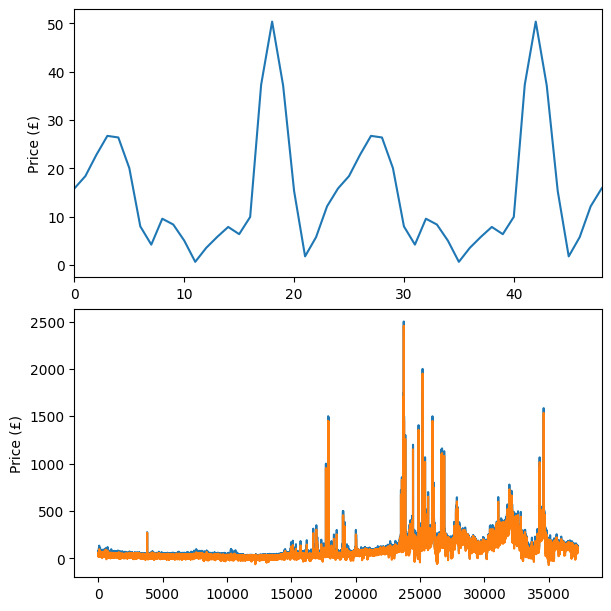

In [226]:
fig, ax = plt.subplots(2,1, figsize=(6,6), constrained_layout=True)
ax[0].plot(abs(ifft_price), label='Primary price mode')
ax[0].set_xlim([0,48])
ax[1].plot(df['Price'], label="N2EX price")
ax[1].plot(df['Price'] - abs(ifft_price), label="N2EX - base fft price")
[i.set_ylabel('Price (£)') for i in ax]
plt.show()

In [228]:
df.head(24)

,UtcDatetime,Price,Volume_MWh
0,2019-01-01 00:00:00,60.12,14.889867
1,2019-01-01 01:00:00,55.76,14.162405
2,2019-01-01 02:00:00,46.23,13.943371
3,2019-01-01 03:00:00,44.10,13.288542
4,2019-01-01 04:00:00,44.41,10.449148
5,2019-01-01 05:00:00,46.03,10.864678
6,2019-01-01 06:00:00,51.00,10.568561
7,2019-01-01 07:00:00,39.00,10.953883
8,2019-01-01 08:00:00,44.17,11.250852
9,2019-01-01 09:00:00,51.30,11.371023


* In the top figure, the cycle is of 24 hours frequency for the price.
* This corresponds to time 00:00:00 to 23:00:00
* For the Price minus FFT base price, a machine learning model using Quantile Regression can be fit

In [229]:
base_fft_price = abs(ifft_price)[:24]
base_fft_price

array([15.86528887, 18.41807218, 22.81043371, 26.73957648, 26.40905488,
       20.05805661,  8.01250061,  4.2317715 ,  9.59455547,  8.39764145,
        5.06565697,  0.67605273,  3.57087252,  5.83137057,  7.89421063,
        6.40435139,  9.9614507 , 37.32069343, 50.38612874, 37.17789585,
       15.33276226,  1.80639407,  5.78235747, 12.16422768])

In [236]:
from math import ceil

In [237]:
num_days = ceil(len(df_copy)/len(base_fft_price))
num_days

1552

In [238]:
base_fft_price_arr = base_fft_price.tolist()*num_days

In [239]:
df_copy['Base Price'] = base_fft_price_arr[:len(df_copy)]

In [242]:
df_copy

,UtcDatetime,Price,Volume_MWh,Base Price
0,2019-01-01 00:00:00,60.12,14.889867,15.865289
1,2019-01-01 01:00:00,55.76,14.162405,18.418072
2,2019-01-01 02:00:00,46.23,13.943371,22.810434
3,2019-01-01 03:00:00,44.10,13.288542,26.739576
4,2019-01-01 04:00:00,44.41,10.449148,26.409055
...,...,...,...,...
37242,2023-04-01 18:00:00,131.64,4.689678,50.386129
37243,2023-04-01 19:00:00,121.29,4.929261,37.177896
37244,2023-04-01 20:00:00,104.99,4.860133,15.332762
37245,2023-04-01 21:00:00,95.01,4.364394,1.806394


##### VERIFYING

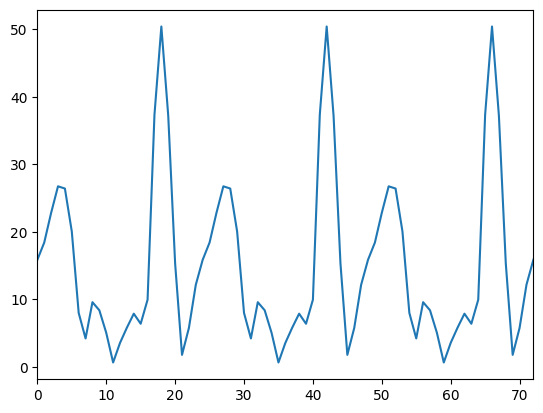

In [243]:
plt.plot(df_copy['Base Price'])
plt.xlim([0,72])
plt.show()

# REGRESSION MODEL: PRICE

* We could use GradientBoostingRegressor for calculating P10 and P90.

## Convert time to Sine and Cosine features

In [248]:
x = df_copy.loc[0,'UtcDatetime']
x

Timestamp('2019-01-01 00:00:00')

In [249]:
x.value

1546300800000000000

In [250]:
df_copy['time_cosine'] = np.cos(df_copy['UtcDatetime'].map(lambda x:x.value))

In [251]:
df_copy['time_sine'] = np.sin(df_copy['UtcDatetime'].map(lambda x:x.value))

In [252]:
df_copy.head(10)

,UtcDatetime,Price,Volume_MWh,Base Price,time_cosine,time_sine
0,2019-01-01 00:00:00,60.12,14.889867,15.865289,0.213888,0.976858
1,2019-01-01 01:00:00,55.76,14.162405,18.418072,0.970275,0.242004
2,2019-01-01 02:00:00,46.23,13.943371,22.810434,0.647588,-0.761991
3,2019-01-01 03:00:00,44.10,13.288542,26.739576,-0.395303,-0.918551
4,2019-01-01 04:00:00,44.41,10.449148,26.409055,-0.998565,-0.053561
5,2019-01-01 05:00:00,46.03,10.864678,20.058057,-0.491291,0.870995
6,2019-01-01 06:00:00,51.00,10.568561,8.012501,0.562363,0.826890
7,2019-01-01 07:00:00,39.00,10.953883,4.231772,0.990595,-0.136826
8,2019-01-01 08:00:00,44.17,11.250852,9.594555,0.317155,-0.948374
9,2019-01-01 09:00:00,51.30,11.371023,8.397641,-0.709004,-0.705205
